<a href="https://colab.research.google.com/github/Tarunreyyi/CodeAlpha_Iris_Flower_Classification/blob/main/CodeAlpha_Iris_Flower_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Iris Flower Classification using Machine Learning

## CodeAlpha Data Science Internship

### Objective
The objective of this project is to develop a machine learning model that can classify Iris flowers into different species based on their sepal and petal measurements.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving CodeAlpha_Iris_Flower_Classification.ipynb to CodeAlpha_Iris_Flower_Classification.ipynb


In [ ]:
df = pd.read_csv('Iris.csv')

df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


## Dataset Information :The Iris dataset contains 150 records and 6 attributes. The dataset includes four numerical features (Sepal Length, Sepal Width, Petal Length, and Petal Width) and one target variable (Species). Using df.info(), it was confirmed that all columns contain 150 non-null values, indicating that there are no missing values in the dataset

In [ ]:
df.isnull().sum()

,0
Id,0
SepalLengthCm,0
SepalWidthCm,0
PetalLengthCm,0
PetalWidthCm,0
Species,0


In [ ]:
df.duplicated().sum()

np.int64(0)

## Exploratory Data AnalysisExploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is the process of examining and understanding the dataset before building a machine learning model. It helps identify the structure of the data, detect any inconsistencies, and gain insights into the relationships between variables.

In this project, the Iris dataset was analyzed to understand the distribution of different flower species. The dataset contains three species: Iris-setosa, Iris-versicolor, and Iris-virginica. Each species is represented by 50 samples, making the dataset balanced and suitable for classification tasks.

The dataset was also checked for missing values and duplicate records. No missing values or duplicate entries were found, indicating that the dataset is clean and ready for further analysis and model training.

The following visualization shows the distribution of flower species in the dataset.

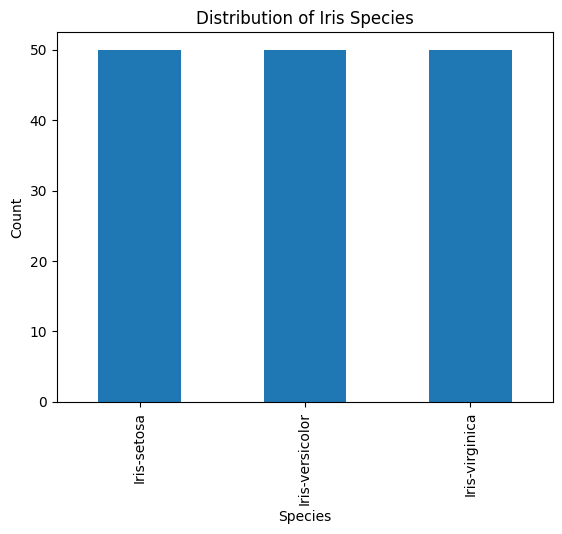

In [ ]:
df['Species'].value_counts().plot(kind='bar')

plt.title('Distribution of Iris Species')
plt.xlabel('Species')
plt.ylabel('Count')

plt.show()

Species Distribution

The distribution of flower species in the Iris dataset was analyzed using a bar chart. The visualization shows that each species (Iris-setosa, Iris-versicolor, and Iris-virginica) contains 50 observations. Since all classes have an equal number of samples, the dataset is balanced and suitable for training a classification model without concerns about class imbalance.

Petal Length vs Petal Width

Petal length and petal width are important features for distinguishing between different Iris flower species. A scatter plot is used to visualize the relationship between these two features. Different species are represented using different colors, making it easier to observe how well the species can be separated based on these measurements.

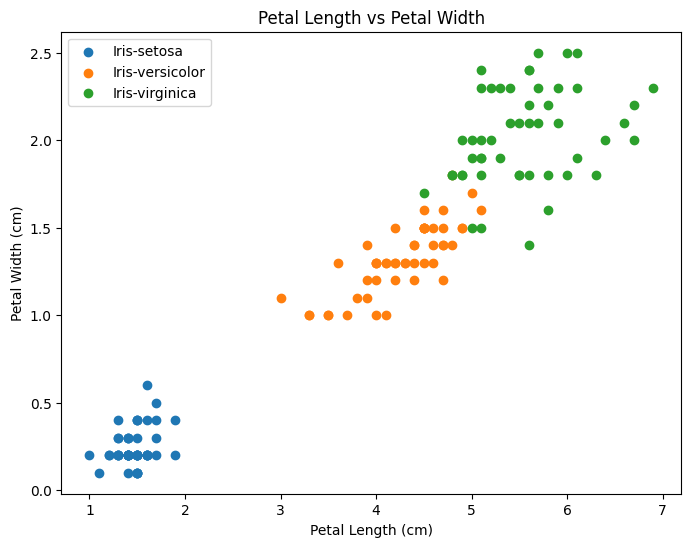

In [ ]:
plt.figure(figsize=(8,6))

for species in df['Species'].unique():
    subset = df[df['Species'] == species]
    plt.scatter(subset['PetalLengthCm'],
                subset['PetalWidthCm'],
                label=species)

plt.title('Petal Length vs Petal Width')
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.legend()
plt.show()

## Feature Selection

Feature selection is the process of choosing the relevant input variables for model training. In the Iris dataset, the flower measurements are used as input features, while the species of the flower is used as the target variable to be predicted.

The selected features are Sepal Length, Sepal Width, Petal Length, and Petal Width. The target variable is Species.

In [ ]:
X = df[['SepalLengthCm',
        'SepalWidthCm',
        'PetalLengthCm',
        'PetalWidthCm']]

y = df['Species']

## Splitting the Dataset
To evaluate the model's performance, the dataset is divided into training and testing sets. The training set is used to train the model, while the testing set is used to evaluate how well the model performs on unseen data.

In this project, 80% of the data is used for training and 20% for testing.






In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Model Training

A Decision Tree Classifier is used for this classification task. Decision Trees are simple, interpretable, and effective machine learning algorithms that can learn patterns from the training data and make predictions on new data.

In [ ]:
model = DecisionTreeClassifier()

model.fit(X_train, y_train)

DecisionTreeClassifier()

## Prediction

After training the model, predictions are generated for the testing dataset. These predictions are then compared with the actual species labels to evaluate the model's performance.

In [ ]:
y_pred = model.predict(X_test)

print(y_pred)

['Iris-versicolor' 'Iris-setosa' 'Iris-virginica' 'Iris-versicolor'
 'Iris-versicolor' 'Iris-setosa' 'Iris-versicolor' 'Iris-virginica'
 'Iris-versicolor' 'Iris-versicolor' 'Iris-virginica' 'Iris-setosa'
 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-versicolor'
 'Iris-virginica' 'Iris-versicolor' 'Iris-versicolor' 'Iris-virginica'
 'Iris-setosa' 'Iris-virginica' 'Iris-setosa' 'Iris-virginica'
 'Iris-virginica' 'Iris-virginica' 'Iris-virginica' 'Iris-virginica'
 'Iris-setosa' 'Iris-setosa']


Evaluate Accuracy

In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 1.0


## Model Evaluation

The performance of the Decision Tree Classifier was evaluated using the testing dataset. The model achieved an accuracy score of 100%, indicating that all test samples were classified correctly. This demonstrates that the selected features provide sufficient information to distinguish between the three Iris flower species.

The high accuracy suggests that the Decision Tree algorithm is highly effective for the Iris classification problem.

In [ ]:
print(classification_report(y_test, y_pred))

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



## Classification Report

The classification report provides detailed evaluation metrics including precision, recall, and F1-score for each flower species. The model achieved a score of 1.00 for all evaluation metrics across all classes, indicating perfect classification performance on the testing dataset.

- Precision measures how many predicted labels were correct.
- Recall measures how many actual samples were correctly identified.
- F1-Score provides a balance between precision and recall.

The results demonstrate that the Decision Tree Classifier effectively learned the patterns present in the Iris dataset and successfully classified all testing samples.

## Conclusion

In this project, a Decision Tree Classifier was developed to classify Iris flowers into three species: Iris-setosa, Iris-versicolor, and Iris-virginica. The dataset was explored, checked for missing values and duplicates, and visualized using exploratory data analysis techniques.

The model was trained using four flower measurements: sepal length, sepal width, petal length, and petal width. After training, the model was evaluated on unseen test data and achieved an accuracy of 100%.

The results indicate that the selected features are highly effective in distinguishing between different Iris species. This project demonstrates the application of machine learning classification techniques and highlights the effectiveness of Decision Tree algorithms for solving classification problems.